<a href="https://colab.research.google.com/github/Kl51Chris/Personal-CodeBase-Control-Robotics-and-etc/blob/main/ECE821/rocket_lander_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECE 821 Optimal Control Project 2026
1111



## Introduction

Vertical Takeoff, Vertical Landing (VTVL) is a form of takeoff and landing for rockets which can allow for reusability. Perhaps the most widely known and successful reusable VTVL vehicle is [SpaceX's Falcon 9](https://www.spacex.com/vehicles/falcon-9) first stage. Reusable rocket technology has been studied extensively in the last two decades, thanks to its many advantages over non-reusable flight systems. These include drastically lowered launch costs, rapid reusability, and reducing the environmental impacts associated with manufacturing.

In this project, you will simulate the final phase of a VTVL misson profile, which is the vertical landing phase. A [Gymnasium](https://gymnasium.farama.org) environment has been developed which simulates the simplified 2D dynamics of a VTVL rocket using the [Box2D](https://box2d.org) physics engine.

The goal of this project is to work in this environment and to develop controllers which are able to guide the descent of the rocket and bring it safely to the landing spot.

<font color='red'>NOTE</font>: We would advise you to run your code in this Colab notebook, which contains the specifications of the control problem, the linearized matrices of the rocket, and the simulator with a basic PID controller already implemented and working. This will help to avoid any compatibility issues across different systems, which we may not be able to help resolve.

## Rocket Dynamics, State, and Action Spaces


A free body diagram illustrating the forces acting on the simplified 2D rocket is shown below. Note that we do not consider air resistance or aerodynamic effects in the 2D model, for simplicity.


<img src="https://gitlab.ethz.ch/bsaverio/coco-project/-/raw/main/images/Rocket_Dynamics.png" width=400/>

### Actions
Three inputs are available for steering the rocket:
- $F_E$: the thrust produced by the main engine in Newtons (N), acting directly on the rocket body at the point where the nozzle pivots;
- $F_S$: the thrust produced by the side gas thrusters in Newtons (N), defined as the difference $F_L - F_R$, acting at a distance $l_2$ from the rocket center of mass;
- $\phi$: the angle of the nozzle with respect to the rocket body in radians (rad), which changes the direction of $F_E$. It can be discontinuous and it has instant response up to the 60 fps frame rate of our model (sampling time of the environment).

The three inputs are provided to the environment as an action:

$$\textbf{u} = \begin{bmatrix}F_E & F_S & \phi\end{bmatrix}$$

which is applied to the environment at the 60 fps frame rate. In other words, your controller must provide 60 actions per second of simulation time. These could be new actions, or the same action could be applied across multiple simulation steps.

Unlike the real world, there is no hard constraint on how long your controller has to produce a next action, although we should be able to run your code in a reasonable amount of time. In our own testing, a well performing optimization-based method took much less than 1 minute to run.

<font color='red'>IMPORTANT</font>: The controller should return *normalized* actions, as a fraction of full scale. The main engine thrust is clipped to $[0, 1]$, while the side engine thrust and nozzle angle is clipped to $[-1, 1]$. The environment then scales these to the appropriate ranges (see [*Limits on the Actuators*](#scrollTo=eb72e2bb&line=11&uniqifier=1)).


### State Variables
The state of the rocket is defined by the following variables:
- $(x, y)$: the 2D position of the rocket center of mass in meters (m);
- $(\dot{x}, \dot{y})$: the velocity of the rocket in meters per second (m/s);
- $\theta$: the angle of the rocket in radians (rad);
- $\dot{\theta}$: the angular velocity of the rocket in radians per second (rad/s);
- $c_L, c_R$: binary variables indicating whether the left or right legs are in contact with the environment, respectively (equal to 0 if no contact and 1 if contact).

The environment returns these variables as an observation:
$$\textbf{x} = \begin{bmatrix}x & y & \dot{x} & \dot{y} & \theta & \dot{\theta}& c_L & c_R\end{bmatrix}$$

The last two variables ($c_L, c_R$) may generally be ignored in your control implementation, but may be useful e.g. for turning off one or more actions once ground contact is made.

<font color='red'>IMPORTANT</font>: All variables are with respect to world frame, which is located in the *bottom-left* corner of the simulation window. The x-axis increases going right (horizontally) along the window and the y-axis increases going up (vertically). Positive angles are measured counter-clockwise from the y-axis.

## Installation

The following lines of code install the necessary packages:

In [1]:
#%%capture
# comment out the above line to display output

!apt install -y swig

%pip install --upgrade pip
%pip install poetry
%pip install 'git+https://github.com/Fireflies3072/rocket-lander.git'

# for rendering video
%pip install pyvirtualdisplay imageio-ffmpeg "moviepy>=1.0"
!sudo apt-get update
!apt-get install -y xvfb ffmpeg

# imports
import os
import random
import gymnasium as gym
import numpy as np
import coco_rocket_lander  # need to import to call gym.make()
from coco_rocket_lander.env import SystemModel
from coco_rocket_lander.algs import PID_RocketLander
import base64
import glob
import io
from IPython.display import HTML
from IPython import display as ipythondisplay
from pyvirtualdisplay import Display
from dataclasses import dataclass
from typing import Optional, Tuple
import warnings
import cvxpy as cp
from cvxpy.atoms.affine.wraps import psd_wrap
YELLOW = "\x1b[33;20m"
ENDL = "\x1b[0m"

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
swig is already the newest version (4.0.2-1ubuntu1).
0 upgraded, 0 newly installed, 0 to remove and 69 not upgraded.
  Cloning https://github.com/Fireflies3072/rocket-lander.git to /tmp/pip-req-build-0pzfitan
  Running command git clone --filter=blob:none --quiet https://github.com/Fireflies3072/rocket-lander.git /tmp/pip-req-build-0pzfitan
  Resolved https://github.com/Fireflies3072/rocket-lander.git to commit 97c779596a12d3b6eee355d13c5a0b5e17e10421
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Ign:3 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Ign:4 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:5 https://r2u.s

## PID Controller

The following code initializes a basic PID controller that can be used to steer the rocket from "ideal" initial conditions of the rocket. We use the PID controller to compute the control actions in the simulation. The following code also illustrates how to interact with the simulator environment.

In [2]:
import gymnasium as gym
import numpy as np
from coco_rocket_lander.algs.pid import PID_RocketLander

args = {
}

# --- Environment Setup ---
env = gym.make("coco_rocket_lander/RocketLander-v0", render_mode="rgb_array", args=args)
env = gym.wrappers.RecordVideo(env, 'video', episode_trigger=lambda x: True, name_prefix="pid_example")

# --- Configuration ---
# PID Parameters
engine_pid_params = [10, 0, 10]
side_engine_pid_params = [5, 0, 6]
engine_vector_pid_params = [0.085, 0.001, 10.55]

# PID controller
pid = PID_RocketLander(engine_pid_params, side_engine_pid_params, engine_vector_pid_params,
                        min_output=env.action_space.low, max_output=env.action_space.high)

# Define the target state for the rocket
# Target: land at the landing position with zero velocity and angle
landing_position = env.unwrapped.get_landing_position()
target = np.zeros(6, dtype=np.float64)
target[0] = landing_position[0]
target[1] = landing_position[1]

# Reset the environment
state, _ = env.reset(seed=0)

for i in range(2000):
    action = pid.update(state[:6], target)
    if i == 0:
        print("raw action:", action)
        print("type(action):", type(action))
        print("np.asarray(action).shape:", np.asarray(action).shape)
        print("np.asarray(action).dtype:", np.asarray(action).dtype)
        print("action_space.contains(action):", env.action_space.contains(np.asarray(action, dtype=env.action_space.dtype)))
    # If the legs are in contact, set both main and side engine thrusts to 0
    if state[6] and state[7]:
        action[:] = 0

    # Apply the calculated action to the environment
    next_state, rewards, done, _, info = env.step(action)

    # Update observation
    state = next_state

    # Check if simulation ended
    if done:
        break

print("Control phase finished.")
env.close()


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /content/video folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


raw action: [ 0.00000000e+00 -4.98861913e-03 -5.45540685e-05]
type(action): <class 'numpy.ndarray'>
np.asarray(action).shape: (3,)
np.asarray(action).dtype: float64
action_space.contains(action): True
Control phase finished.


In [3]:
print("action_space:", env.action_space)
print("action low:", env.action_space.low)
print("action high:", env.action_space.high)

action_space: Box([ 0. -1. -1.], 1.0, (3,), float64)
action low: [ 0. -1. -1.]
action high: [1. 1. 1.]


### View the Video

The above code specifies to save the video in a folder called `video`. We can open this folder to look at the recorded episode as follows. First, we define a `show_video` method for convenience:


In [4]:
# set up `show_video` function for Google Colab

# create a display
display = Display(visible=0, size=(1400, 900))
display.start()

# play back the video
def show_video(prefix: str):
  mp4list = glob.glob('video/*.mp4')
  if len(mp4list) > 0:
    mp4list = [os.path.basename(name) for name in mp4list]
    valid_videos = [name for name in mp4list if name.startswith(prefix)]
    if len(valid_videos) == 0:
      raise FileNotFoundError(f"Did not find a video starting with '{prefix}'. Found: {mp4list}")
    if len(valid_videos) > 1:
      raise ValueError(f"Found multiple videos starting with '{prefix}', please be more specific! Found: {valid_videos}")
    mp4 = valid_videos[0]  # we should only have one
    video = io.open('video/' + mp4, 'r+b').read()
    encoded_video = base64.b64encode(video).decode('ascii')
    ipythondisplay.display(HTML(data=f'''<video alt="test" autoplay loop controls style="height: 400px;">
                         <source src="data:video/mp4;base64,{encoded_video}" type="video/mp4" />
                       </video>'''))
  else:
    print("Did not find any files ending with .mp4 in the video folder!")

Then we invoke this method to play the video with title prefix `pid_example` in the `video` folder:

In [5]:
show_video('pid_example')

## Linearized Model of the Rocket Problem

A basic linearized model of the rocket dynamics has been derived and is provided to you with the discrete-time update equation of the form

$$\textbf{x}_{k+1} = A \textbf{x}_{k} + B\textbf{u}_{k}.$$
<!-- $$\dot{\textbf{x}} = A \textbf{x} + B\textbf{u}$$ -->
 <!-- $$\textbf{x}_{t+1} = A \textbf{x}_{t} + B\textbf{u}_{t}.$$ -->

Note:
- This equation assumes that we have discarded the last two elements ($c_L, c_R$) of the state observation $\textbf{x}$ returned by the environment;
- The $A$ matrix has shape $\mathbb{R}^{6\times 6}$ and $x_k$, $x_{k+1}$ vectors have shape $\mathbb{R}^{6\times 1}$;
- The $B$ matrix has shape $\mathbb{R}^{6\times3}$ and $u_k$ vector has shape $\mathbb{R}^{3\times 1}$;
- We linearize around the upright equilibrium with action $\tilde{\textbf{u}} = \begin{bmatrix} mg & 0 & 0 \end{bmatrix}$

Moreover, $x$ and $A$ are unnormalized, but $u_k$ is normalized. We need to multiply a coefficient matrix with $u_k$ to get the unnormalized(actual) input.

  $$u_\text{k,unnormalized} =
  \begin{bmatrix}
    F_{E, \textrm{max}} & 0 & 0\\
    0 & F_{S, \textrm{max}} & 0\\
    0 & 0 & \phi_{\textrm{max}}
  \end{bmatrix} u_k$$

We scale $B$ such that *normalized actions* (as a fraction of full scale) satisfy the update equation. The normalization of $B$ is performed as follows:

  $$B_\text{unnormalized} u_\text{k,unnormalized} = \left(B_\text{unnormalized}
  \begin{bmatrix}
    F_{E, \textrm{max}} & 0 & 0\\
    0 & F_{S, \textrm{max}} & 0\\
    0 & 0 & \phi_{\textrm{max}}
  \end{bmatrix}\right)u_k = B u_k$$

  $$B = B_\textrm{unnormalized}
  \begin{bmatrix}
    F_{E, \textrm{max}} & 0 & 0\\
    0 & F_{S, \textrm{max}} & 0\\
    0 & 0 & \phi_{\textrm{max}}
  \end{bmatrix}$$

where $B_\textrm{unnormalized}$ is simply the usual linearized, discrete-time input matrix obtained from the system dynamics. The maximum values used for scaling are given in the following section, [*Limits on the Actuators*](#scrollTo=eb72e2bb&line=11&uniqifier=1).

The following code demonstrates how to obtain the system matrices:

In [6]:
env = gym.make("coco_rocket_lander/RocketLander-v0", render_mode="rgb_array", args={})

model = SystemModel(env)

# by default, linearize around upright equilibrium with F_E = m*g
model.calculate_linear_system_matrices()

# you are free to change the sampling time as you wish
model.discretize_system_matrices(sample_time=0.1)
A, B = model.get_discrete_linear_system_matrices()

print("A:\n", A.round(3), "\n"*2, "B:\n", B.round(3))


A:
 [[ 1.     0.     0.1    0.    -0.049 -0.002]
 [ 0.     1.     0.     0.1    0.     0.   ]
 [ 0.     0.     1.     0.    -0.981 -0.049]
 [ 0.     0.     0.     1.     0.     0.   ]
 [ 0.     0.     0.     0.     1.     0.1  ]
 [ 0.     0.     0.     0.     0.     1.   ]] 

 B:
 [[ 0.000e+00  3.000e-03 -1.300e-02]
 [ 1.520e-01  0.000e+00  0.000e+00]
 [ 0.000e+00  6.200e-02 -2.520e-01]
 [ 3.039e+00  0.000e+00  0.000e+00]
 [ 0.000e+00 -3.000e-03 -1.600e-02]
 [ 0.000e+00 -5.700e-02 -3.210e-01]]


## Specifications of the Control Problem

### Limits on the Actuators

The following limits should be assumed for the normalized actions to the enivornment:

- $F_E \in [0, 1]$;
- $F_S \in [-1, 1]$;
- $\phi \in [-1 ,1]$

That is, $\textbf{u} \in [0,1]\times [-1,1] \times [-1,1]$.

Actions outside this range will be clipped. These are then multiplied by the actual maximum thrust/angle limits to get the value which is applied to the environment. The maximum values can be queried as follows:

In [7]:
print(f"Main engine max. thrust (F_E,max): {env.unwrapped.cfg.main_engine_thrust}")
print(f"Side engine max. thrust (F_S,max): {env.unwrapped.cfg.side_engine_thrust}")
print(f"Max. absolute nozzle angle (phi_max) (in radians): {env.unwrapped.cfg.max_nozzle_angle}")

Main engine max. thrust (F_E,max): 16118.518518518518
Side engine max. thrust (F_S,max): 322.3703703703704
Max. absolute nozzle angle (phi_max) (in radians): 0.2617993877991494


The limits can also be directly queried from the environment:

In [8]:
print(f"Main engine normalized thrust limits: {env.unwrapped.cfg.main_engine_thrust_limits}")
print(f"Side engine normalized thrust limits: {env.unwrapped.cfg.side_engine_thrust_limits}")
print(f"Nozzle normalized angle limits: {env.unwrapped.cfg.nozzle_angle_limits}")

Main engine normalized thrust limits: (0.0, 1.0)
Side engine normalized thrust limits: (-1.0, 1.0)
Nozzle normalized angle limits: (-1.0, 1.0)


### Limits on the State
The following limits should be assumed for the state:

- $x \in [0, 33.333]$;
- $y \in [0, 26.666]$;
- $\theta \in [-0.6108, 0.6108]$ (i.e., $[-35°,35°]$)

These are the *maximal* limits for the simulation, and the simulation will terminate if these are exceeded. Your controller should at least consider these limits on the state space.

There are no enforced limits on the linear or angular velocity. Of course, the simulator steps forwards at 60 frames per second and there is some velocity at which the rocket will exit the allowable state space in a single timestep.

<font color='red'>IMPORTANT</font>: Note that the environment exclusively uses *radians* for angles.

These values can also be directly queried from the environment:

In [9]:
print(f"State x limits: {[0, env.unwrapped.cfg.width]}")
print(f"State y limits: {[0, env.unwrapped.cfg.height]}")
print(f"State angle limits (in radians): {[-env.unwrapped.cfg.theta_limit, env.unwrapped.cfg.theta_limit]}")

State x limits: [0, 33.333333333333336]
State y limits: [0, 26.666666666666668]
State angle limits (in radians): [-0.6108652381980153, 0.6108652381980153]


### Landing Constraints
By default, the landing barge is placed halfway across the screen and 1/8th of the way up, unless changed on initialization (see [*Arguments Provided to the Environment*](#scrollTo=eb9d6a9e) below). The landing position can be queried from the environment at runtime as:

In [10]:
landing_position = env.unwrapped.get_landing_position()  # 3-tuple (x_des, y_des, theta_des)
print(f"Landing position (x, y, theta): {landing_position}")

Landing position (x, y, theta): [np.float64(16.66666603088379), np.float64(7.4796546662204), 0.0]


Where $x_\mathrm{des}$, $y_\mathrm{des}$ and $\theta_\mathrm{des}$ is the desired 2D position and angle of the rocket such that it lands on the center of the barge.

<font color='red'>IMPORTANT</font>: For simplicity of implementation, we return the position of the rocket center of mass *above* the barge that the rocket center of mass should be at for a successful landing. We also subtract a small fudge factor of 0.15m such that the rocket legs actually trigger a contact with the barge.

#### Successful Landings

If the rocket legs make contact with the sea, or if the rocket body makes contact with anything, we immediately terminate the environment. The rocket legs may otherwise make contact with any part of the landing platform.

If both rocket legs make contact with the landing platform and the rocket stops moving, the landing will be considered successful. The environment will return `done = True`. If the environment terminates for any other reason, the environment will also return `done = True`.

### Arguments Provided to the Environment

Initialization arguments can be provided to the environment in a dictionary. We've defined several arguments which a user may provide to test different aspects of the simulation. The following is an excerpt of the relevant code:

In [11]:
@dataclass
class UserArgs:
    """User arguments for tweaking the environment"""

    initial_position: Optional[Tuple[float, ...]] = None  # 3-tuple (x, y, theta)
    initial_state: Optional[
        Tuple[float, ...]
    ] = None  # 6-tuple (x, y, x_dot, y_dot, theta, theta_dot)

    initial_barge_position: Optional[Tuple[float, ...]] = None  # 2-tuple (x, theta)

    # render crosses at the rocket center of mass and landing position
    render_landing_position: bool = True
    render_lander_center_position: bool = True

    # disturbances, which should generally be left disabled
    enable_wind: bool = False
    enable_moving_barge: bool = False

    random_initial_position: bool = False

<font color='red'>IMPORTANT</font>: The values $x$ and $y$ are provided as a fraction of the screen width and height, for simplicity. All other values $( \theta, \dot{\theta}, \dot{x}, \dot{y})$ use their normal units of rad, rad/s, and m/s, respectively.

For example, to initialize the rocket a quarter of the way across the screen, halfway up, and at an angle of 0.1 rad, the following arguments could be provided:

In [12]:
args = {
    "initial_position": (0.25, 0.5, 0.1) # (x, y, theta) x: 0(leftmost)-1(rightmost) y: 0(downmost)-1(uppermost)
}

env = gym.make("coco_rocket_lander/RocketLander-v0", render_mode="rgb_array", args=args)

### Other Useful Methods and Parameters

The following additional methods and parameters may be of some use during your implementation.

In [13]:
gravity = env.unwrapped.cfg.gravity  # fixed at -9.81
mass, inertia = env.unwrapped.get_mass_properties()
l1, l2 = env.unwrapped.get_dimensional_properties()

# normalized main engine thrust to compensate for gravity
gravity_comp_fraction = -gravity * mass / env.unwrapped.cfg.main_engine_thrust

print(f"Gravity: {gravity}")
print(f"Mass, Inertia: {mass, inertia}")
print(f"l1, l2: {l1, l2}")
print(f"Gravity compensation fraction: {gravity_comp_fraction}")

Gravity: -9.81
Mass, Inertia: (530.4058532714844, 1209.53515625)
l1, l2: (2.8466666666666667, 2.1350000000000002)
Gravity compensation fraction: 0.3228138748989386


---
# Your Code Goes Below Here
---

Note: Please run the entire Colab Notebook in one go before submitting to ensure it is working.

## Failure Scenario for the Baseline PID Controller

In realistic operations, the rocket may begin with non-zero horizontal velocity and initial attitude error due to wind, navigation mismatch, or late guidance corrections. These are plausible off-nominal conditions (not extreme or physically absurd) that can stress a PID tuned near nominal operation.

This section keeps the original PID demo unchanged and adds a reusable simulation workflow:

- run a baseline case using default reset behavior;
- run an off-nominal case via `env.reset(options=...)`;
- if needed, perform a small sweep over `(theta0, xdot0)` to identify a robust failure case;
- generate comparison plots and a compact numeric summary.

The same selected failure scenario should be reused later for advanced-controller comparison so both controllers are tested under identical conditions.


In [40]:
import matplotlib.pyplot as plt

def make_failure_args(
    x0=0.5,
    y0=0.9,
    xdot0=0.0,
    ydot0=0.0,
    theta0=0.0,
    thetadot0=0.0,
):
    return {
        "initial_state": (
            x0,
            y0,
            xdot0,
            ydot0,
            theta0,
            thetadot0,
        ),
        "random_initial_position": False,
    }


def _classify_outcome(done, info, final_state, landing_position=None):
    """Best-effort outcome label using info + final state heuristics.

    A successful landing means:
    - near the landing target,
    - low velocity,
    - near upright attitude,
    - preferably both legs in contact if contact flags are available.
    """
    if not done:
        return "time_limit"

    # only trust informative info labels; ignore vague labels like "unknown"
    for key in ["status", "event", "termination_reason", "done_reason", "result"]:
        value = info.get(key)
        if value is not None:
            value = str(value)

            if value.lower() not in ["unknown", "none", ""]:
                return value

    x, y, xdot, ydot, theta, thetadot = final_state[:6]

    # leg contact flags exist in the 8-state observation
    if len(final_state) >= 8:
        left_leg_contact = bool(final_state[6])
        right_leg_contact = bool(final_state[7])
        both_legs_down = left_leg_contact and right_leg_contact
    else:
        both_legs_down = True

    gentle_velocity = (
        abs(xdot) < 0.25
        and abs(ydot) < 0.35
        and abs(thetadot) < 0.8
    )

    upright = abs(theta) < 0.35

    if landing_position is not None:
        x_land = float(landing_position[0])
        y_land = float(landing_position[1])

        near_platform = (
            abs(x - x_land) < 0.75
            and abs(y - y_land) < 0.75
        )
    else:
        near_platform = True

    if both_legs_down and near_platform and gentle_velocity and upright:
        return "landed_on_platform"

    if both_legs_down and gentle_velocity and upright and not near_platform:
        return "off_target_landing"

    if both_legs_down and not gentle_velocity:
        return "hard_landing_or_crash"

    if not upright:
        return "bad_attitude"

    if abs(xdot) >= 0.25 or abs(ydot) >= 0.35:
        return "high_velocity_termination"

    return "terminated_non_landing"


def run_pid_simulation(env_args=None, max_steps=600, video_prefix=None, seed=0):
    """Run one PID episode and return trajectories + summary metadata."""
    if env_args is None:
        env_args = {}

    sim_env = gym.make(
        "coco_rocket_lander/RocketLander-v0",
        render_mode="rgb_array",
        args=env_args,
    )

    if video_prefix is not None:
        sim_env = gym.wrappers.RecordVideo(
            sim_env,
            "video",
            episode_trigger=lambda x: True,
            name_prefix=video_prefix,
        )

    sim_pid = PID_RocketLander(
        engine_pid_params,
        side_engine_pid_params,
        engine_vector_pid_params,
        min_output=sim_env.action_space.low,
        max_output=sim_env.action_space.high,
    )

    state, info = sim_env.reset(seed=seed)

    landing_position = sim_env.unwrapped.get_landing_position()
    target = np.zeros(6, dtype=np.float64)
    target[0] = landing_position[0]
    target[1] = landing_position[1]

    states = [state.copy()]
    actions = []
    rewards = []
    done = False

    for _ in range(max_steps):
        action = sim_pid.update(state[:6], target)

        if state[6] and state[7]:
            action[:] = 0

        next_state, reward, terminated, truncated, step_info = sim_env.step(action)

        actions.append(action.copy())
        rewards.append(reward)
        states.append(next_state.copy())

        state = next_state
        info = step_info

        if terminated or truncated:
            done = True
            break

    sim_env.close()

    states = np.asarray(states, dtype=np.float64)
    actions = (
        np.asarray(actions, dtype=np.float64)
        if len(actions)
        else np.zeros((0, 3), dtype=np.float64)
    )
    rewards = np.asarray(rewards, dtype=np.float64)

    outcome = _classify_outcomeoutcome = _classify_outcome(
    done,
    info if isinstance(info, dict) else {},
    states[-1],
    landing_position,
)

    return {
        "states": states,
        "actions": actions,
        "rewards": rewards,
        "done": bool(done),
        "steps": len(actions),
        "final_state": states[-1],
        "info": info if isinstance(info, dict) else {},
        "outcome": outcome,
        "landing_position": landing_position,
        "env_args": env_args,
    }


In [41]:
def summarize_run(name, result):
    fs = result["final_state"]
    print(f"[{name}] outcome={result['outcome']}, done={result['done']}, steps={result['steps']}")
    print(f"  final pose    : x={fs[0]:.3f}, y={fs[1]:.3f}, theta={fs[4]:.3f}")
    print(f"  final velocity: xdot={fs[2]:.3f}, ydot={fs[3]:.3f}, thetadot={fs[5]:.3f}")


baseline_result = run_pid_simulation(env_args=None,max_steps=600,video_prefix="pid_baseline",)
## match theta with velocity
v0= -3
theta0=0.25
xdot0 = v0 * np.sin(theta0)
ydot0 = v0 * np.cos(theta0)
proposed_failure_args = make_failure_args(theta0=theta0,xdot0=xdot0,ydot0=ydot0)
failure_result = run_pid_simulation(env_args=proposed_failure_args,max_steps=600,video_prefix="pid_failure_trial",)
# #{
# if failure_result["outcome"] == "landed":
#     print("Initial off-nominal trial still landed. Running a small sweep to find a failure case...")
#     candidate = None
#     theta_grid = [0.15, 0.20, 0.25, 0.30, 0.33]
#     xdot_grid = [0.0, 0.2, 0.35, 0.5]

#     for theta0 in theta_grid:
#         for xdot0 in xdot_grid:
#             proposed_failure_args = make_failure_args(theta0=theta0,xdot0=xdot0)
#             result = run_pid_simulation(env_args=proposed_failure_args,max_steps=600,video_prefix="pid_failure_trial",)
#             if result["outcome"] != "landed":
#                 candidate = {"theta0": theta0,"xdot0": xdot0,"env_args": options,"result": result,}
#                 print(f"Selected failure from sweep: theta0={theta0:.2f}, xdot0={xdot0:.2f}, outcome={result['outcome']}")
#                 break
#         if candidate is not None:
#             break

#     if candidate is not None:
#         selected_theta0 = candidate["theta0"]
#         selected_xdot0 = candidate["xdot0"]
#         selected_options = candidate["env_args"]
#         selected_result = candidate["result"]
#         print("Selected sweep candidate:")
#         print("theta0:", selected_theta0)
#         print("xdot0:", selected_xdot0)
#         print("selected_options:", selected_options)
#         print("initial_state:", selected_options["initial_state"])
#         print("outcome:", selected_result["outcome"])
#         print("steps:", selected_result["steps"])
#         failure_result = run_pid_simulation(env_args=selected_options,max_steps=600,video_prefix="pid_failure_trial",)
#     else:
#         print("Sweep did not find a strict failure label; keeping the off-nominal case for comparison.")
# #}
print("Compact summary:")
summarize_run("Baseline", baseline_result)
summarize_run("Failure scenario", failure_result)


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /content/video folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:433: UserWarning: WARN: Unable to save last video! Did you call close()?
  logger.warn("Unable to save last video! Did you call close()?")


Compact summary:
[Baseline] outcome=landed_on_platform, done=True, steps=348
  final pose    : x=16.612, y=7.583, theta=0.015
  final velocity: xdot=0.000, ydot=0.000, thetadot=0.000
[Failure scenario] outcome=high_velocity_termination, done=True, steps=232
  final pose    : x=10.120, y=7.351, theta=0.038
  final velocity: xdot=-2.837, ydot=-0.617, thetadot=-0.187


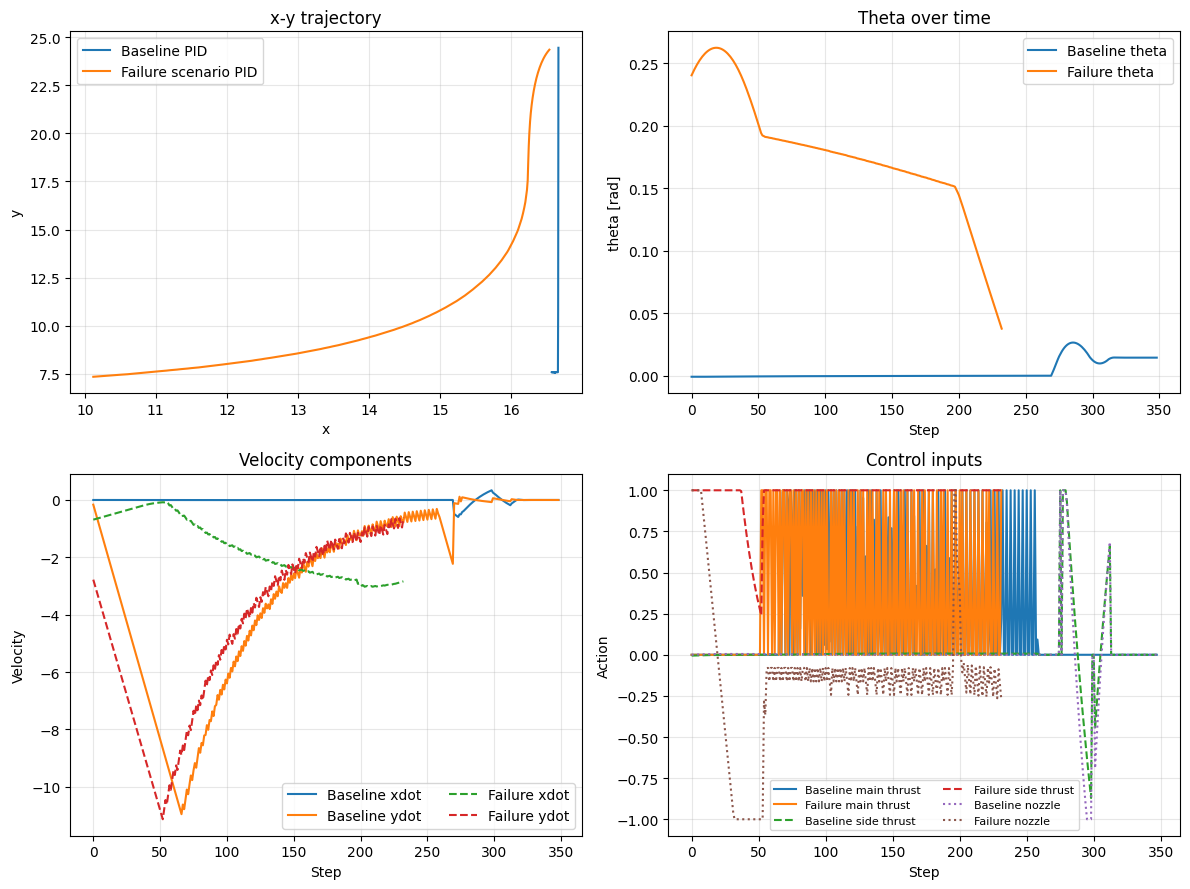

In [42]:
def plot_pid_comparison(baseline, failure):
    b_states, f_states = baseline["states"], failure["states"]
    b_actions, f_actions = baseline["actions"], failure["actions"]

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))

    axes[0, 0].plot(b_states[:, 0], b_states[:, 1], label="Baseline PID")
    axes[0, 0].plot(f_states[:, 0], f_states[:, 1], label="Failure scenario PID")
    axes[0, 0].set_title("x-y trajectory")
    axes[0, 0].set_xlabel("x")
    axes[0, 0].set_ylabel("y")
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(b_states[:, 4], label="Baseline theta")
    axes[0, 1].plot(f_states[:, 4], label="Failure theta")
    axes[0, 1].set_title("Theta over time")
    axes[0, 1].set_xlabel("Step")
    axes[0, 1].set_ylabel("theta [rad]")
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    axes[1, 0].plot(b_states[:, 2], label="Baseline xdot")
    axes[1, 0].plot(b_states[:, 3], label="Baseline ydot")
    axes[1, 0].plot(f_states[:, 2], '--', label="Failure xdot")
    axes[1, 0].plot(f_states[:, 3], '--', label="Failure ydot")
    axes[1, 0].set_title("Velocity components")
    axes[1, 0].set_xlabel("Step")
    axes[1, 0].set_ylabel("Velocity")
    axes[1, 0].legend(ncol=2)
    axes[1, 0].grid(True, alpha=0.3)

    if len(b_actions) and len(f_actions):
        axes[1, 1].plot(b_actions[:, 0], label="Baseline main thrust")
        axes[1, 1].plot(f_actions[:, 0], label="Failure main thrust")
        axes[1, 1].plot(b_actions[:, 1], '--', label="Baseline side thrust")
        axes[1, 1].plot(f_actions[:, 1], '--', label="Failure side thrust")
        axes[1, 1].plot(b_actions[:, 2], ':', label="Baseline nozzle")
        axes[1, 1].plot(f_actions[:, 2], ':', label="Failure nozzle")
    axes[1, 1].set_title("Control inputs")
    axes[1, 1].set_xlabel("Step")
    axes[1, 1].set_ylabel("Action")
    axes[1, 1].legend(ncol=2, fontsize=8)
    axes[1, 1].grid(True, alpha=0.3)

    fig.tight_layout()
    plt.show()


plot_pid_comparison(baseline_result, failure_result)


In [43]:
show_video("pid_baseline")

In [44]:
show_video("pid_failure_trial")

In [45]:
env = gym.make(
    "coco_rocket_lander/RocketLander-v0",
    render_mode="rgb_array",
    args={}
)

state, info = env.reset(seed=0)

print("initial state:", state[:6])
print("landing_position:", env.unwrapped.get_landing_position())
print("env width:", env.unwrapped.cfg.width)
print("env height:", env.unwrapped.cfg.height)

env.close()

initial state: [ 1.66684456e+01  2.44449863e+01  0.00000000e+00 -1.63500011e-01
 -6.41812570e-04  0.00000000e+00]
landing_position: [np.float64(16.66666603088379), np.float64(7.4796546662204), 0.0]
env width: 33.333333333333336
env height: 26.666666666666668


## Linear MPC Controller (Added Below PID/Failure Section)

This section adds a linear MPC architecture without modifying the existing PID code.

- MPC uses only `state[:6] = [x, y, xdot, ydot, theta, thetadot]`.
- The target is defined from `env.unwrapped.get_landing_position()` **after** `env.reset(...)`.
- Linear dynamics matrices are taken directly from `A, B = model.get_discrete_linear_system_matrices()`.
- The MPC action is directly the normalized 3D command accepted by `env.step(action)`.
- Actuator constraints are read from `env.action_space.low/high`.
- At each step, MPC applies only the first optimized action and replans (receding horizon).

In [54]:
# %pip install cvxpy
import cvxpy as cp


class LinearMPCController:
    def __init__(self, A, B, horizon, Q, R, Qf, u_min, u_max, theta_max=None, solver="OSQP"):
        self.A = np.asarray(A, dtype=float)
        self.B = np.asarray(B, dtype=float)
        self.horizon = int(horizon)
        self.nx = self.A.shape[0]
        self.nu = self.B.shape[1]

        self.Q = np.asarray(Q, dtype=float)
        self.R = np.asarray(R, dtype=float)
        self.Qf = np.asarray(Qf, dtype=float)
        self.u_min = np.asarray(u_min, dtype=float)
        self.u_max = np.asarray(u_max, dtype=float)
        self.theta_max = theta_max
        self.solver = solver
        self.fallback_action = np.array([0.0, 0.0, 0.0], dtype=float)

    def update(self, state, target):
        x0 = np.asarray(state, dtype=float).reshape(-1)
        ref = np.asarray(target, dtype=float).reshape(-1)

        x = cp.Variable((self.nx, self.horizon + 1))
        u = cp.Variable((self.nu, self.horizon))

        constraints = [x[:, 0] == x0]
        objective = 0

        for k in range(self.horizon):
            dx = x[:, k] - ref
            objective += cp.quad_form(dx, self.Q) + cp.quad_form(u[:, k], self.R)
            constraints += [x[:, k + 1] == self.A @ x[:, k] + self.B @ u[:, k]]
            constraints += [u[:, k] >= self.u_min, u[:, k] <= self.u_max]
            if self.theta_max is not None:
                constraints += [x[4, k] >= -self.theta_max, x[4, k] <= self.theta_max]

        objective += cp.quad_form(x[:, self.horizon] - ref, self.Qf)
        if self.theta_max is not None:
            constraints += [x[4, self.horizon] >= -self.theta_max, x[4, self.horizon] <= self.theta_max]

        problem = cp.Problem(cp.Minimize(objective), constraints)

        try:
            problem.solve(solver=getattr(cp, self.solver), warm_start=True)
            if u.value is None:
                return self.fallback_action.copy()
            action = np.array(u.value[:, 0], dtype=float)
            return np.clip(action, self.u_min, self.u_max)
        except Exception:
            return self.fallback_action.copy()


def run_mpc_simulation(
    env_args,
    model,
    max_steps=2000,
    seed=0,
    horizon=25,
    Q=None,
    R=None,
    Qf=None,
    theta_max=0.6,
    video_prefix=None,
):
    env = gym.make("coco_rocket_lander/RocketLander-v0", render_mode="rgb_array", args=env_args)

    if video_prefix is not None:
         env = gym.wrappers.RecordVideo(env,video_folder="video",episode_trigger=lambda episode_id: True,name_prefix=video_prefix,)

    state, info = env.reset(seed=seed)
    landing_position = env.unwrapped.get_landing_position()
    ### debug check if inital position is correct
    print("env_args:", env_args)

    if isinstance(env_args, dict) and "initial_state" in env_args:
        desired = np.array(env_args["initial_state"], dtype=float)
        actual = np.array(state[:6], dtype=float)

        print("desired initial_state:", desired)
        print("actual state[:6]:     ", actual)
        print("difference:           ", actual - desired)
    #### end of debug
    target = np.array([
        landing_position[0],
        landing_position[1],
        0.0,
        0.0,
        landing_position[2],
        0.0,
    ], dtype=float)

    A, B = model.get_discrete_linear_system_matrices()
    u_min = env.action_space.low.astype(float)
    u_max = env.action_space.high.astype(float)

    if Q is None:
        Q = np.diag([10.0, 20.0, 2.0, 4.0, 30.0, 4.0])
    if R is None:
        R = np.diag([0.2, 0.2, 0.5])
    if Qf is None:
        Qf = 10.0 * Q

    print("MPC action_space:", env.action_space)
    print("MPC model shapes:", A.shape, B.shape)
    print("MPC target:", target)

    mpc = LinearMPCController(
        A=A,
        B=B,
        horizon=horizon,
        Q=Q,
        R=R,
        Qf=Qf,
        u_min=u_min,
        u_max=u_max,
        theta_max=theta_max,
        solver="OSQP",
    )

    states = [np.array(state, dtype=float)]
    actions, rewards, infos = [], [], [info]
    done = truncated = False

    first_action_logged = False

    for _ in range(max_steps):
        action = mpc.update(state[:6], target)

        if (state[6] and state[7]):
            action[:] = 0.0

        if not first_action_logged:
            print("First MPC action:", action)
            first_action_logged = True

        next_state, reward, done, truncated, info = env.step(action)

        actions.append(np.array(action, dtype=float))
        rewards.append(float(reward))
        states.append(np.array(next_state, dtype=float))
        infos.append(info)

        state = next_state
        if done or truncated:
            break

    env.close()
    #debug: check if inital condition is in there

    print("env_args:", env_args)

    states = np.array(states)
    actions = np.array(actions)
    rewards = np.array(rewards)

    result = {
        "states": states,
        "actions": actions,
        "rewards": rewards,
        "final_state": states[-1],
        "done": done,
        "truncated": truncated,
        "steps": len(actions),
        "info": info,
        "infos": infos,
        "target": target,
        "landing_position": np.array(landing_position, dtype=float),
        "controller": "Linear MPC",
        "outcome": _classify_outcome(done,info if isinstance(info, dict) else {},states[-1],landing_position,),
    }

    # optional, if infer_landing_outcome is already defined


    return result

In [55]:
# Reuse existing PID failure args if present; otherwise replace placeholder below.
if "proposed_failure_args" in globals():
    mpc_failure_env_args = proposed_failure_args
    print("proposed_failure_args:")
    print(proposed_failure_args)
else:
    # Replace this with the same env_args used for the PID failure scenario.
    mpc_failure_env_args = {}

# Example run (easy to comment out if not needed):
mpc_failure_result = run_mpc_simulation(
    env_args=mpc_failure_env_args,
    model=model,
    max_steps=2000,
    seed=0,
    horizon=25,
    theta_max=0.6,
    video_prefix="mpc_failure_trial",
)



proposed_failure_args:
{'initial_state': (0.5, 0.9, np.float64(-0.7422118777635688), np.float64(-2.9067372651319343), 0.25, 0.0), 'random_initial_position': False}
env_args: {'initial_state': (0.5, 0.9, np.float64(-0.7422118777635688), np.float64(-2.9067372651319343), 0.25, 0.0), 'random_initial_position': False}
desired initial_state: [ 0.5         0.9        -0.74221188 -2.90673727  0.25        0.        ]
actual state[:6]:      [16.54079628 24.3457489  -0.68600261 -2.77796841  0.24043849  0.14716747]
difference:            [ 1.60407963e+01  2.34457489e+01  5.62092656e-02  1.28768858e-01
 -9.56150889e-03  1.47167474e-01]
MPC action_space: Box([ 0. -1. -1.], 1.0, (3,), float64)
MPC model shapes: (6, 6) (6, 3)
MPC target: [16.66666603  7.47965467  0.          0.          0.          0.        ]


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /content/video folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


First MPC action: [0. 1. 1.]


/tmp/ipykernel_32286/3220808309.py:47: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=getattr(cp, self.solver), warm_start=True)


env_args: {'initial_state': (0.5, 0.9, np.float64(-0.7422118777635688), np.float64(-2.9067372651319343), 0.25, 0.0), 'random_initial_position': False}


In [58]:
mpc_failure_result["outcome"] = _classify_outcome(
    mpc_failure_result["done"],
    mpc_failure_result["info"] if isinstance(mpc_failure_result.get("info"), dict) else {},
    mpc_failure_result["final_state"],
    mpc_failure_result["landing_position"],
)
summarize_run("MPC failure", mpc_failure_result)


[MPC failure] outcome=landed_on_platform, done=True, steps=170
  final pose    : x=16.562, y=7.577, theta=0.021
  final velocity: xdot=0.000, ydot=0.000, thetadot=0.000


In [23]:
# @title
def plot_failure_comparison(pid_result, mpc_result):
    """
    Compare PID and MPC performance under the same failure scenario.
    This version improves readability when trajectories overlap.
    """

    pid_states = np.asarray(pid_result["states"])
    mpc_states = np.asarray(mpc_result["states"])

    pid_actions = np.asarray(pid_result["actions"])
    mpc_actions = np.asarray(mpc_result["actions"])

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))

    # helper for marker spacing
    def marker_every(arr, n_markers=12):
        if len(arr) <= n_markers:
            return 1
        return max(1, len(arr) // n_markers)

    pid_markevery = marker_every(pid_states)
    mpc_markevery = marker_every(mpc_states)

    # =========================
    # x-y trajectory
    # =========================
    ax = axes[0, 0]

    ax.plot(
        pid_states[:, 0],
        pid_states[:, 1],
        linestyle="-",
        linewidth=3.0,
        alpha=0.55,
        label="PID under failure scenario",
        zorder=2,
    )

    ax.plot(
        mpc_states[:, 0],
        mpc_states[:, 1],
        linestyle="--",
        linewidth=2.2,
        marker="o",
        markersize=4,
        markevery=mpc_markevery,
        alpha=0.95,
        label="MPC under same scenario",
        zorder=3,
    )

    # start markers
    ax.scatter(
        pid_states[0, 0],
        pid_states[0, 1],
        marker="s",
        s=70,
        label="PID start",
        zorder=5,
    )
    ax.scatter(
        mpc_states[0, 0],
        mpc_states[0, 1],
        marker="^",
        s=80,
        label="MPC start",
        zorder=6,
    )

    # end markers
    ax.scatter(
        pid_states[-1, 0],
        pid_states[-1, 1],
        marker="x",
        s=90,
        linewidths=2,
        label="PID end",
        zorder=5,
    )
    ax.scatter(
        mpc_states[-1, 0],
        mpc_states[-1, 1],
        marker="*",
        s=140,
        label="MPC end",
        zorder=6,
    )

    # small annotations
    ax.annotate(
        "PID start",
        xy=(pid_states[0, 0], pid_states[0, 1]),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=8,
    )
    ax.annotate(
        "MPC start",
        xy=(mpc_states[0, 0], mpc_states[0, 1]),
        xytext=(8, -14),
        textcoords="offset points",
        fontsize=8,
    )
    ax.annotate(
        "PID end",
        xy=(pid_states[-1, 0], pid_states[-1, 1]),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=8,
    )
    ax.annotate(
        "MPC end",
        xy=(mpc_states[-1, 0], mpc_states[-1, 1]),
        xytext=(8, -14),
        textcoords="offset points",
        fontsize=8,
    )

    ax.set_title("x-y trajectory")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # =========================
    # attitude over time
    # =========================
    ax = axes[0, 1]

    ax.plot(
        pid_states[:, 4],
        linestyle="-",
        linewidth=2.5,
        alpha=0.65,
        label="PID theta",
    )
    ax.plot(
        mpc_states[:, 4],
        linestyle="--",
        linewidth=2.2,
        marker="o",
        markersize=3,
        markevery=mpc_markevery,
        label="MPC theta",
    )

    ax.scatter(0, pid_states[0, 4], marker="s", s=55, zorder=5)
    ax.scatter(0, mpc_states[0, 4], marker="^", s=65, zorder=6)

    ax.set_title("Attitude over time")
    ax.set_xlabel("Step")
    ax.set_ylabel("theta [rad]")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # =========================
    # velocity components
    # =========================
    ax = axes[1, 0]

    ax.plot(
        pid_states[:, 2],
        linestyle="-",
        linewidth=2.3,
        alpha=0.65,
        label="PID xdot",
    )
    ax.plot(
        pid_states[:, 3],
        linestyle="-.",
        linewidth=2.3,
        alpha=0.65,
        label="PID ydot",
    )
    ax.plot(
        mpc_states[:, 2],
        linestyle="--",
        linewidth=2.0,
        marker="o",
        markersize=3,
        markevery=mpc_markevery,
        label="MPC xdot",
    )
    ax.plot(
        mpc_states[:, 3],
        linestyle=":",
        linewidth=2.5,
        marker="x",
        markersize=4,
        markevery=mpc_markevery,
        label="MPC ydot",
    )

    ax.set_title("Velocity components")
    ax.set_xlabel("Step")
    ax.set_ylabel("Velocity")
    ax.legend(ncol=2, fontsize=8)
    ax.grid(True, alpha=0.3)

    # =========================
    # control inputs
    # =========================
    ax = axes[1, 1]

    if len(pid_actions) > 0:
        ax.plot(
            pid_actions[:, 0],
            linestyle="-",
            linewidth=2.4,
            alpha=0.6,
            label="PID main thrust",
        )
        ax.plot(
            pid_actions[:, 1],
            linestyle="-.",
            linewidth=2.0,
            alpha=0.6,
            label="PID side thrust",
        )
        ax.plot(
            pid_actions[:, 2],
            linestyle=":",
            linewidth=2.4,
            alpha=0.6,
            label="PID nozzle",
        )

    if len(mpc_actions) > 0:
        action_markevery = marker_every(mpc_actions)

        ax.plot(
            mpc_actions[:, 0],
            linestyle="--",
            linewidth=2.0,
            marker="o",
            markersize=3,
            markevery=action_markevery,
            label="MPC main thrust",
        )
        ax.plot(
            mpc_actions[:, 1],
            linestyle="--",
            linewidth=2.0,
            marker="x",
            markersize=4,
            markevery=action_markevery,
            label="MPC side thrust",
        )
        ax.plot(
            mpc_actions[:, 2],
            linestyle=":",
            linewidth=2.8,
            marker=".",
            markersize=5,
            markevery=action_markevery,
            label="MPC nozzle",
        )

    ax.set_title("Control inputs")
    ax.set_xlabel("Step")
    ax.set_ylabel("Action")
    ax.legend(ncol=2, fontsize=8)
    ax.grid(True, alpha=0.3)

    fig.suptitle(
        "Failure Scenario: PID vs MPC",
        fontsize=14,
        fontweight="bold",
    )

    fig.tight_layout()
    plt.show()

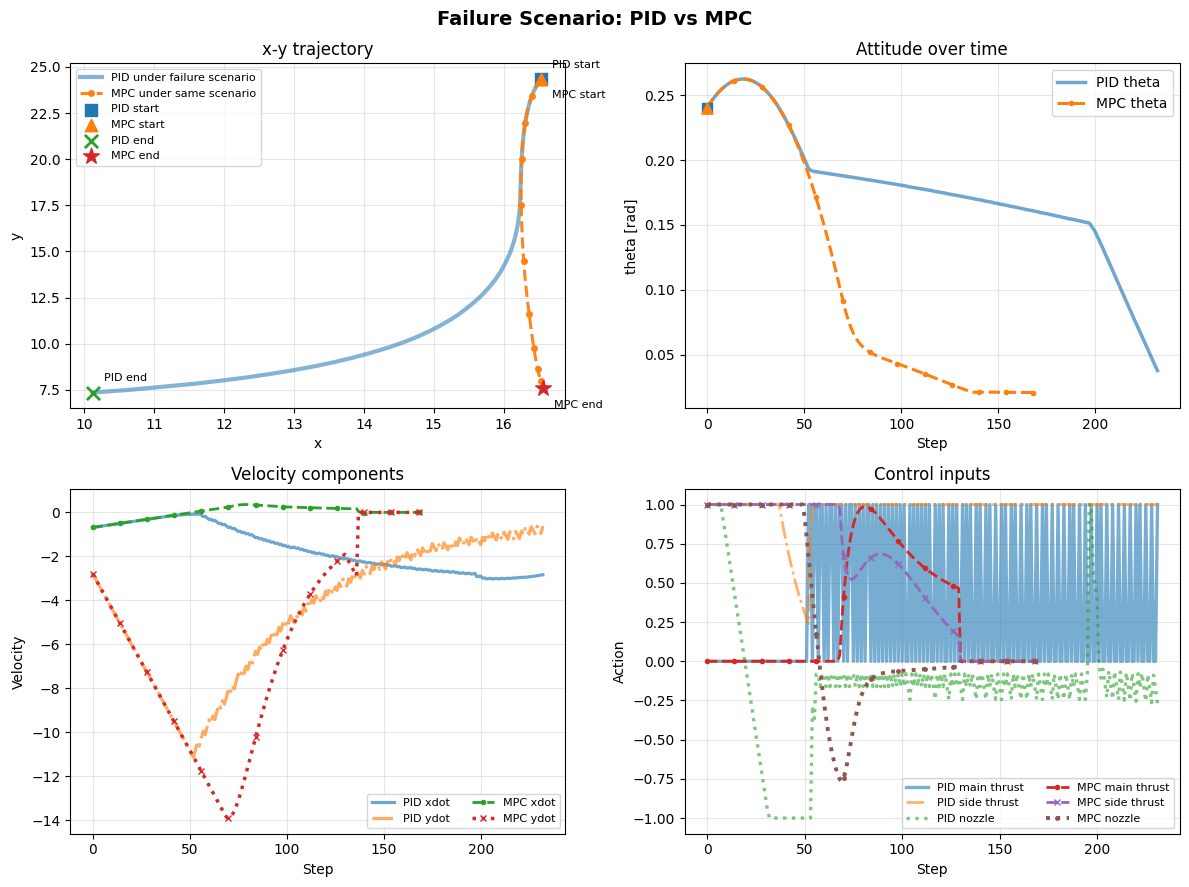

In [59]:
plot_failure_comparison(pid_result=failure_result,mpc_result=mpc_failure_result,)

In [25]:
show_video("pid_failure_trial")
show_video("mpc_failure_trial")

In [26]:
print("landing_position:", mpc_failure_result["landing_position"])
print("target:", mpc_failure_result["target"])
print("initial state:", mpc_failure_result["states"][0, :6])
print("final state:", mpc_failure_result["final_state"][:6])

landing_position: [16.66666603  7.47965467  0.        ]
target: [16.66666603  7.47965467  0.          0.          0.          0.        ]
initial state: [16.54079628 24.3457489  -0.68600261 -2.77796841  0.24043849  0.14716747]
final state: [16.56234169  7.57718992  0.          0.          0.02095695  0.        ]


In [27]:
print("PID failure initial:", failure_result["states"][0][:6])
print("MPC failure initial:", mpc_failure_result["states"][0][:6])
print("diff:", mpc_failure_result["states"][0][:6] - failure_result["states"][0][:6])

PID failure initial: [16.54079628 24.3457489  -0.68600261 -2.77796841  0.24043849  0.14716747]
MPC failure initial: [16.54079628 24.3457489  -0.68600261 -2.77796841  0.24043849  0.14716747]
diff: [0. 0. 0. 0. 0. 0.]


In [28]:
last = mpc_failure_result["states"][-1]

print("last from states:", last[:8])
print("target:", mpc_failure_result["target"])
print("landing_position:", mpc_failure_result["landing_position"])

last from states: [16.56234169  7.57718992  0.          0.          0.02095695  0.
  1.          1.        ]
target: [16.66666603  7.47965467  0.          0.          0.          0.        ]
landing_position: [16.66666603  7.47965467  0.        ]
